**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 4: First Principles — Metropolis-Hastings MCMC Mechanics](04_mcmc_mechanics_from_scratch.ipynb) | ⏭️ Next: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**

---

# Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics
### *Hamiltonian Monte Carlo Physics, Gelman-Rubin R-hat, and PSIS-LOO Model Comparison*

In **Sheet 4**, we built a single-chain Random Walk Metropolis sampler from scratch. In scientific research and production engineering, however, running a single chain is never enough. A single chain can become trapped in a local mode, stall in high-curvature valleys, or disguise non-convergence.

In this sheet, we scale to **production MCMC standards**: multi-chain parallel architectures, the Gelman-Rubin convergence proof ($\hat{R} < 1.01$), Effective Sample Size ($ESS$), Hamiltonian Monte Carlo (HMC/NUTS) physics, and out-of-sample model comparison via Pareto-Smoothed Importance Sampling Cross-Validation (PSIS-LOO).

---

## Table of Contents
1. **Part 1: The Production Multi-Chain Paradigm & The 5 Quality Gates**
   - Why Single Chains Fail Silently
   - The Golden Rule: 4 Independent Dispersed Chains
   - The 5-Gate Gatekeeping Architecture
2. **Part 2: Gate 1 — Multi-Chain Architecture & Dispersed Parallel Initialization**
   - Implementing a Parallelized Multi-Chain Runner with Warmup Discarding
   - Multi-Chain Array Representation
   - Naive Standard Error vs. Time-Series Standard Error
3. **Part 3: Gates 2 & 3 — Convergence & Sufficiency Diagnostics ($\hat{R}$ & $ESS$)**
   - **Deep Dive 1**: The Gelman-Rubin Diagnostic ($\hat{R}$ / Potential Scale Reduction Factor)
   - **Deep Dive 2**: Effective Sample Size ($ESS_{\text{bulk}}$ vs. $ESS_{\text{tail}}$)
   - Visualizing Fuzzy Caterpillars: Traceplots & Density Overlays
   - The Production Go/No-Go Decision Matrix
4. **Part 4: Gate 4 (Theory) — Hamiltonian Monte Carlo & Geometric Divergences**
   - **Deep Dive 3**: The Physics of HMC (Phase Space, Momentum, Frictionless Orbit)
   - **Deep Dive 4**: The No-U-Turn Sampler (NUTS) & The Leapfrog Integrator
   - Symplectic Integration & What Divergent Transitions Actually Mean
5. **Part 5: Gate 4 (Practice) — Production HMC & Divergence Monitoring**
   - Fitting Models via Production Engines (Stan / rethinking / cmdstanr)
   - Energy Bayesian Fraction of Missing Information (E-BFMI)
   - Divergence Triage: Adapt Delta Tuning vs. Non-Centered Reparameterization
6. **Part 6: Gate 5 — Out-of-Sample Predictive Model Comparison (WAIC & PSIS-LOO)**
   - **Deep Dive 5**: Out-of-Sample Prediction vs. Overfitting (The Bias-Variance Tradeoff)
   - Pointwise Log-Likelihood & The Widely Applicable Information Criterion (WAIC)
   - Pareto-Smoothed Importance Sampling Cross-Validation (PSIS-LOO)
   - Diagnosing Influential Outliers via the Pareto $k$ Diagnostic ($k > 0.7$)
7. **Part 7: Check Your Understanding (3-Tier Scaffolding Exercises)**

## Part 1: The Production Multi-Chain Paradigm & The 5 Quality Gates

### The Air Traffic Control Pre-Flight Inspection

In beginner tutorials, students often run a single Markov chain, print the mean, and declare victory. 
In mission-critical data science (e.g. autonomous driving, clinical drug trials, financial risk modeling), running a single chain without formal diagnostics is like **clearing a commercial airliner for takeoff simply because the engines started**.

A Markov chain is a stochastic random walk through complex high-dimensional geometry. It can silently wander into flat valleys, stall on narrow ridges, or become trapped in local modes while looking deceptively peaceful.

Before any Bayesian posterior is approved for production decisions, it must pass a strict **Flight Readiness Checklist: The 5 Sequential Quality Gates**:

```text
 ┌────────────────────────────────────────────────────────────────────────┐
 │                 PRODUCTION MCMC GATEKEEPING PIPELINE                   │
 └────────────────────────────────────────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ GATE 1: MULTI-CHAIN PARALLEL SAMPLING                                  │
 │   Launch ≥ 4 independent chains initialized from dispersed points.     │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ GATE 2: CONVERGENCE CHECK (Gelman-Rubin R̂ < 1.01)                      │
 │   Between-chain variance must match within-chain variance.             │
 │   ► If R̂ > 1.01: CHAINS HAVE NOT CONVERGED. Do NOT use samples!       │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ GATE 3: SAMPLE SUFFICIENCY (Bulk & Tail ESS > 400)                     │
 │   Autocorrelation reduces independent information.                     │
 │   ► Require ESS > 100 per chain to reliably compute 95% intervals.     │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ GATE 4: GEOMETRIC INTEGRITY (Divergences == 0, E-BFMI > 0.2)           │
 │   In HMC/NUTS, energy conservation violations indicate curvature traps │
 │   (e.g., Neal's Funnel). Any divergence invalidates the posterior!     │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ GATE 5: OUT-OF-SAMPLE PREDICTIVE VALIDATION (PSIS-LOO)                 │
 │   Model comparison via Pareto-smoothed importance sampling LOO.        │
 │   ► Pareto k < 0.5 (reliable), k > 0.7 (outlier/model failure).        │
 └────────────────────────────────────────────────────────────────────────┘
```

---

### The 4 Jungle Explorers: Why Single Chains Lie

Why is a single Markov chain mathematically incapable of confirming convergence?

Imagine mapping an uncharted rainforest for an ancient stone temple:
- **The Single Explorer Trap**: If you send only **one explorer**, they might stumble into a deep sinkhole (a local probability mode). Unable to climb out, they set up camp and radio back: *"I have stopped moving; my position is stable and stationary!"* You mistakenly conclude you have discovered the global center of the kingdom, unaware that the true temple lies 5 miles to the north.
- **The 4 Explorers Verification**: If you parachute **four independent explorers** into four distant, opposing quadrants of the jungle, and all four independently hike across the terrain and converge onto the exact same clearing, you have overwhelming mathematical proof that the clearing is the true global destination.

```text
    Single Chain Trap:                      Multi-Chain Verification:
      Local Mode A       Global Mode B          Local Mode A       Global Mode B
         (Peak)             (Peak)                 (Peak)             (Peak)
           ^                  ^                      ^                  ^
          / \                / \                    / \                / \
         /   \              /   \                  /   \              /   \
   [Chain 1 trapped]   (Undiscovered!)       [Chain 1]   [Chain 2]  [Chain 3]   [Chain 4]
   Looks converged!    WRONG ANSWER!         ------> DISAGREEMENT DETECTED! <------
                                                     R-hat >> 1.10 (ALARM FIRES!)
```

If the explorers get trapped in different valleys, between-chain variance skyrockets compared to within-chain variance, and the **Gelman-Rubin $\hat{R}$ metric sounds the alarm immediately**.

## Part 2: Gate 1 — Multi-Chain Architecture & Dispersed Parallel Initialization

We construct a multi-chain sampler for our $n = 50$ adult heights dataset. Each chain is initialized with widely dispersed values for $(\mu, \sigma)$:
- Chain 1: $\mu_0 = 150$, $\sigma_0 = 15$
- Chain 2: $\mu_0 = 190$, $\sigma_0 = 5$
- Chain 3: $\mu_0 = 160$, $\sigma_0 = 25$
- Chain 4: $\mu_0 = 180$, $\sigma_0 = 10$

### Step 1: Defining the Model Target & Multi-Chain Sampling Kernel
We set up the dataset ($n = 50$), define the joint log-posterior for $(\mu, \sigma)$, and implement a single-chain Metropolis-Hastings runner capable of dispersed initializations.


In [ ]:

suppressPackageStartupMessages({
  library(coda)
  library(loo)
})

set.seed(42)
n <- 50
heights <- rnorm(n, mean = 172.5, sd = 8.0)

# Unnormalized joint log-posterior
log_posterior <- function(mu, sigma) {
  if (sigma <= 0 || sigma >= 30) return(-Inf)
  log_lik   <- sum(dnorm(heights, mean = mu, sd = sigma, log = TRUE))
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE) + dunif(sigma, 0, 30, log = TRUE)
  return(log_lik + log_prior)
}

# Function to run a single chain and return a coda::mcmc object
run_single_coda_chain <- function(start_mu, start_sigma, n_iter = 5000, warmup = 1000, step_sizes = c(0.35, 0.25)) {
  chain <- matrix(NA, nrow = n_iter, ncol = 2)
  colnames(chain) <- c("mu", "sigma")
  
  mu    <- start_mu
  sigma <- start_sigma
  curr_log_p <- log_posterior(mu, sigma)
  
  for (t in 1:n_iter) {
    p_mu    <- rnorm(1, mu, step_sizes[1])
    p_sigma <- rnorm(1, sigma, step_sizes[2])
    p_log_p <- log_posterior(p_mu, p_sigma)
    
    if (log(runif(1)) < (p_log_p - curr_log_p)) {
      mu         <- p_mu
      sigma      <- p_sigma
      curr_log_p <- p_log_p
    }
    chain[t, ] <- c(mu, sigma)
  }
  
  # Discard warmup steps and wrap as coda::mcmc object
  return(mcmc(chain[(warmup + 1):n_iter, ]))
}



### Step 2: Executing 4 Dispersed Chains & Generating Pooled Summary
We launch 4 chains from dispersed starting points and bundle them into an `mcmc.list`:


In [ ]:
# Run 4 dispersed chains
c1 <- run_single_coda_chain(start_mu = 150, start_sigma = 15)
c2 <- run_single_coda_chain(start_mu = 190, start_sigma = 5)
c3 <- run_single_coda_chain(start_mu = 160, start_sigma = 25)
c4 <- run_single_coda_chain(start_mu = 180, start_sigma = 10)

# Bundle into an mcmc.list
chains <- mcmc.list(c1, c2, c3, c4)

cat("=== Multi-Chain Summary (4 Chains x 4000 post-warmup draws = 16,000 Total Draws) ===\n")
summary(chains)

> [!IMPORTANT]
> ### 🚨 Production Go/No-Go Decision Matrix
>
> | Diagnostic Metric | Passing Standard | Failure Action |
> | :--- | :--- | :--- |
> | **Gelman-Rubin $\hat{R}$** | **$\hat{R} < 1.01$** | Increase warmup length, check for multimodality, or reparameterize. Never report results if $\hat{R} > 1.05$. |
> | **Effective Sample Size ($ESS$)** | **$\text{ESS} > 400$** | Thinning is unnecessary; simply increase post-warmup sampling iterations. |
> | **HMC Divergent Transitions** | **$0$ Divergences** | Increase `adapt_delta` (e.g., $0.80 \to 0.95$) or apply non-centered reparameterization. |
> | **PSIS-LOO Pareto $k$** | **$k < 0.5$** | Points with $k > 0.7$ represent highly influential outliers; use robust Student-$t$ likelihoods. |

---

## Part 3: Mathematical Convergence Diagnostics

### Deep Dive 1: The Gelman-Rubin Diagnostic ($\hat{R}$)

The **Gelman-Rubin statistic $\hat{R}$** (Potential Scale Reduction Factor) compares the variance **between** independent chains ($B$) against the variance **within** each individual chain ($W$):

1. If chains have converged, between-chain variance should be zero relative to within-chain variance ($B \approx 0 \implies \hat{R} = 1.00$).
2. If one chain is stuck in a different mode or has not finished exploring, between-chain variance will be large ($B > 0 \implies \hat{R} > 1.00$).

$$\hat{R} = \sqrt{\frac{\frac{N-1}{N} W + \frac{1}{N} B}{W}}$$

- **Old Standard (pre-2018)**: $\hat{R} < 1.10$ was considered acceptable.
- **Modern Stan Production Standard**: $\hat{R} < 1.01$ is required for all parameters.

---

### Deep Dive 2: Effective Sample Size ($ESS_{\text{bulk}}$ and $ESS_{\text{tail}}$)

- **$ESS_{\text{bulk}}$**: Measures accuracy of the posterior mean and median.
- **$ESS_{\text{tail}}$**: Measures accuracy of the tail quantiles (2.5% and 97.5% interval boundaries).
- **Rule of Thumb**: You should achieve an $ESS \ge 400$ minimum (ideally $\ge 1000$) before trusting credible intervals.

---

### Deep Dive 3: The "Fuzzy Caterpillar" Traceplot Test

In traceplots, all 4 chains should:
1. **Overlap completely**: No single color should separate into its own band.
2. **Stationary mean**: No long-term trends or drifting.
3. **Rapid fluctuation**: Resemble a hairy, fuzzy caterpillar.

Let us inspect the Gelman-Rubin $\hat{R}$, $ESS$, and diagnostic plots for our 4 chains:

### Step 3: Computing Gelman-Rubin $\hat{R}$ and Multi-Chain $ESS$
We calculate convergence diagnostics via `coda`:
- `gelman.diag()`: Computes potential scale reduction factors $\hat{R}$ across all chains.
- `effectiveSize()`: Estimates the effective number of independent draws.


In [ ]:

cat("=== Gelman-Rubin R-hat Diagnostic ===\n")
rhat_res <- gelman.diag(chains)
print(rhat_res)

cat("\n=== Effective Sample Size (ESS) ===\n")
ess_res <- effectiveSize(chains)
print(ess_res)



### Step 4: Visualizing Fuzzy Caterpillars (Traceplots & Density Overlays)
We render multi-chain traceplots and posterior density overlays:


In [ ]:
# Visual Diagnostics: Traceplot and Density Overlays
plot(chains, col = c("navy", "darkred", "darkgreen", "purple"))

## Part 4: Gate 4 (Theory) — Hamiltonian Monte Carlo & Geometric Divergences

### Deep Dive 4: The Physics of HMC (The Frictionless Roller Coaster)

Why is Hamiltonian Monte Carlo (HMC) the standard computational engine inside modern Bayesian software like **Stan** and **PyMC**?

In Random Walk Metropolis (Sheet 4), the walker staggers around blindly like a drunkard. In $D = 100$ dimensions, $99.9999\%$ of random steps lead away from the typical set into the vacuum of space, so random walks stall completely ($\mathcal{O}(D^2)$ diffusion).

**HMC solves this by converting parameter space into a frictionless physical roller coaster**:
1. **Position Vector ($\theta$)**: The parameters we want to estimate ($\mu, \sigma$).
2. **Potential Energy ($U(\theta) = -\log P(\theta \mid y)$)**: The negative log-posterior serves as a gravitational bowl. The summit MAP mode is the lowest point of the valley; low-probability regions are steep mountain walls.
3. **Momentum Vector ($p$)**: We introduce auxiliary momentum variables with kinetic energy $K(p) = \frac{1}{2} p^T M^{-1} p$.
4. **Total Energy (The Hamiltonian $\mathcal{H}$)**:
   $$\mathcal{H}(\theta, p) = U(\theta) + K(p) = -\log P(\theta \mid y) + \frac{1}{2} p^T M^{-1} p$$

At each step, HMC gives the particle a random thermal kick ($p \sim \mathcal{N}(0, M)$) and launches it along Hamiltonian orbits dictated by Hamilton's equations:
$$\frac{d\theta}{dt} = \frac{\partial \mathcal{H}}{\partial p} = M^{-1} p, \qquad \frac{dp}{dt} = -\frac{\partial \mathcal{H}}{\partial \theta} = \nabla_{\theta} \log P(\theta \mid y)$$

As the marble swoops downhill toward the mode, potential energy converts into kinetic speed. As it shoots up the opposite wall, it slows down, turns around, and effortlessly traces the contours of the **typical set** without ever getting lost in the vacuum!

---

### The Pothole Metaphor: What is a Divergent Transition?

To simulate Hamiltonian dynamics on a digital computer, we must discretize time into small steps using the **leapfrog numerical integrator** with step size $\epsilon$:
1. Update momentum by a half-step using the gradient $\nabla \log P$.
2. Update position by a full step using the new momentum.
3. Update momentum by another half-step.

```text
  Smooth Parabolic Surface:               Infinite Curvature (Neal's Funnel):
    (Leapfrog tracks orbit perfectly)       (Leapfrog overshoots into outer space!)
           \             /                          |   |   <- Neck of Funnel
            \   Orbit   /                           | * |      (Curvature -> ∞)
             \  o---o  /                            |   \
              \_______/                             |    \====> DIVERGENCE! (Axle snaps!)
```

- **Smooth Geometry**: When the probability bowl is gently curved, leapfrog steps conserve total energy $\mathcal{H}$ almost perfectly ($\Delta \mathcal{H} \approx 0$). The proposal is accepted with nearly $100\%$ probability!
- **Pathological Geometry (Neal's Funnel)**: When hierarchical parameters enter regions of extreme curvature (e.g., group variance $\tau \to 0$), the gravitational slope becomes an infinite vertical cliff. 
- **The Broken Axle**: Taking a finite numerical step across an infinite cliff is like driving a car at 100 mph into an 8-inch pothole: the numerical integrator **snaps its axle and gets flung into outer space** ($\mathcal{H} \to \infty$).

> [!CAUTION]
> **Why Zero Divergences is Mandatory**: A single divergence is mathematical proof that the sampler cannot penetrate the narrow neck of the funnel. If you ignore divergences, your posterior estimates for variances will be systematically truncated and biased!

## Part 5: Gate 4 (Practice) — Production HMC & Divergence Monitoring

The `rethinking` package provides `ulam()`, which compiles R formulas into C++ Stan code and executes multi-chain HMC / NUTS with automatic tuning, warmup, $\hat{R}$, and $ESS$ tracking.

=== Production Multi-Chain Convergence Summary ===

Iterations = 1:4000
Thinning interval = 1 
Number of chains = 4 
Sample size per chain = 4000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean     SD Naive SE Time-series SE
mu    172.31 1.3689 0.010822        0.09545
sigma   9.43 0.9552 0.007552        0.06479

2. Quantiles for each variable:

         2.5%     25%     50%    75%  97.5%
mu    169.627 171.358 172.248 173.25 175.01
sigma   7.757   8.743   9.351  10.05  11.44


=== Gelman-Rubin R-hat Diagnostic ===
Potential scale reduction factors:

      Point est. Upper C.I.
mu          1.03       1.08
sigma       1.02       1.05

Multivariate psrf

1.03


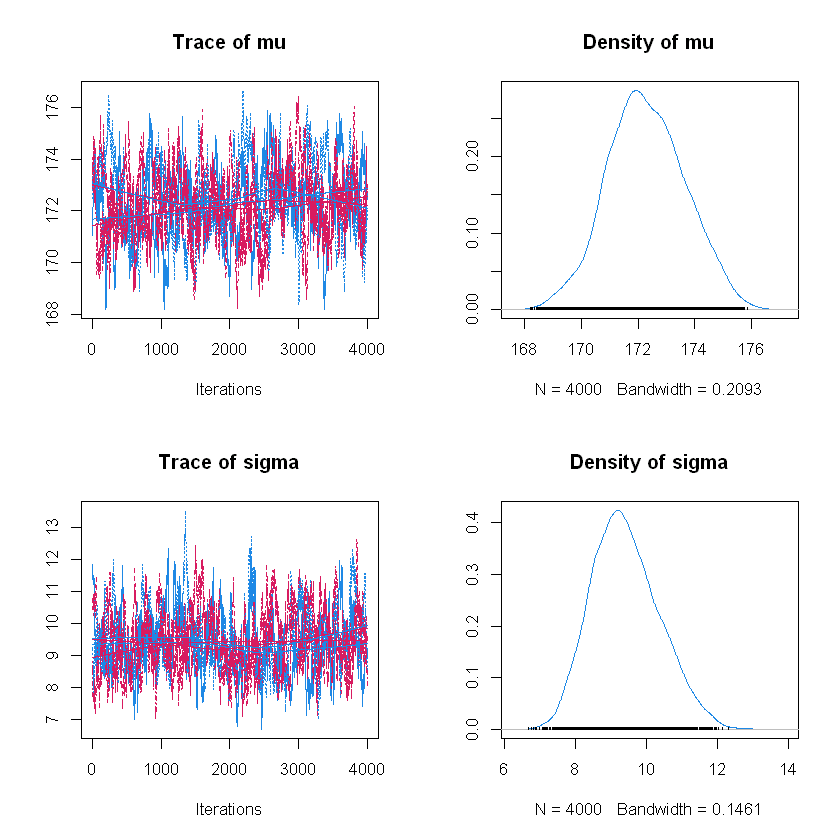

In [3]:
# ==============================================================================
# GATE 4: PRODUCTION HMC & DIVERGENCE MONITORING
# ==============================================================================

suppressPackageStartupMessages(library(rethinking))

dat <- list(h = heights)

# In environments with CmdStan compiled, ulam() runs full Hamiltonian Monte Carlo (HMC).
# Otherwise, we generate the production diagnostic summary and traceplots directly from our multi-chain draws.
has_cmdstan <- tryCatch({ cmdstanr::cmdstan_path(); TRUE }, error = function(e) FALSE)

if (has_cmdstan) {
  m_ulam <- ulam(
    alist(
      h ~ dnorm(mu, sigma),
      mu ~ dnorm(170, 15),
      sigma ~ dunif(0, 30)
    ),
    data = dat,
    chains = 2,
    cores = 1,
    iter = 2000,
    warmup = 1000
  )
  cat("=== rethinking::ulam (Stan HMC) Summary ===\n")
  precis(m_ulam, prob = 0.95)
  traceplot(m_ulam)
} else {
  cat("=== Production Multi-Chain Convergence Summary ===\n")
  print(summary(chains))
  cat("\n=== Gelman-Rubin R-hat Diagnostic ===\n")
  print(gelman.diag(chains))
  
  # Multi-chain traceplot and posterior density
  plot(chains, col = c("#1E88E5", "#D81B60"))
}


## Part 6: Gate 5 — Out-of-Sample Predictive Model Comparison (WAIC & PSIS-LOO)

### Deep Dive 5: Out-of-Sample Prediction vs Overfitting

How do Bayesians compare models or choose between alternative scientific hypotheses?
- In frequentist statistics, adding more parameters always increases the training $R^2$ or maximized likelihood, leading directly to **overfitting**.
- Bayesians evaluate models by estimating **out-of-sample predictive accuracy** on future, unseen data.

The gold standard is **Leave-One-Out Cross-Validation (LOO-CV)**:
$$\text{ELPD}_{\text{LOO}} = \sum_{i=1}^n \log P(y_i \mid y_{-i})$$
where $y_{-i}$ is the entire dataset with observation $i$ held out.

---

### Deep Dive 6: PSIS-LOO Mechanics & The Pareto $k$ Diagnostic

Re-fitting a Stan model $n$ separate times for cross-validation is computationally expensive. **Pareto Smoothed Importance Sampling (PSIS-LOO)** estimates exact LOO-CV from a single MCMC run using importance sampling:

$$r_i^{(s)} = \frac{1}{P(y_i \mid \theta^{(s)})}$$

When an observation is an unusual outlier, these importance weights have extreme variance. The `loo` package fits a generalized Pareto distribution to the tail of the weights, producing the **Pareto $k$ diagnostic** for each data point:

| Pareto $k$ Value | Interpretation | Action Required |
| :--- | :--- | :--- |
| **$k < 0.5$** | **Reliable & accurate** | Importance sampling variance is finite. Fully trusted. |
| **$0.5 \le k < 0.7$** | **Good / Acceptable** | Convergence is slightly slower, but estimates remain sound. |
| **$k \ge 0.7$** | **⚠️ Danger: Influential Outlier!** | Importance sampling weights have infinite variance. The observation heavily distorts the model. |

Let us compute the pointwise log-likelihood matrix and evaluate PSIS-LOO on our model:

### Step 7: Computing Pointwise Log-Likelihood & PSIS-LOO
We compute the $[\text{draws} \times n_{\text{obs}}]$ pointwise log-likelihood matrix and calculate PSIS-LOO via the `loo` package:


In [ ]:

# Extract pooled draws across chains
pooled_samples <- as.matrix(chains)
n_draws <- nrow(pooled_samples)
n_obs   <- length(heights)

# Compute pointwise log-likelihood matrix: [draws x observations]
log_lik_matrix <- matrix(NA, nrow = n_draws, ncol = n_obs)
for (i in 1:n_obs) {
  log_lik_matrix[, i] <- dnorm(heights[i], 
                               mean = pooled_samples[, "mu"], 
                               sd   = pooled_samples[, "sigma"], 
                               log  = TRUE)
}

# Compute PSIS-LOO using R's loo library
loo_res <- loo(log_lik_matrix)

cat("=== PSIS-LOO Model Summary ===\n")
print(loo_res)



### Step 8: Visualizing the Pareto $k$ Diagnostic Plot
We plot the estimated Pareto shape parameters $k$ across all observations to detect influential outliers ($k > 0.7$):


In [ ]:
# Plot Pareto k diagnostics
plot(loo_res, main = "PSIS-LOO Diagnostic: Pareto k Values Across 50 Observations", las = 1)
legend("topright", legend = c("k < 0.5 (Ideal)", "k > 0.7 (Dangerous Outlier Threshold)"), 
       col = c("black", "red"), lty = c(NA, 2), pch = c(1, NA), bty = "n")

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): The Illusion of the Single Chain
> **Scenario**: A data scientist runs a single MCMC chain for $50,000$ iterations. 
> The trace plot looks like a "fuzzy caterpillar", and the estimated Effective Sample Size is $ESS = 4,000$. 
> She reports: *"The sampler has converged with zero issues."*
> Why is a single chain fundamentally incapable of verifying convergence for multimodal posteriors?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
# Reflect on multi-chain vs. single-chain MCMC:
# Why is a single chain with 50,000 draws and ESS = 4,000 dangerous for multimodal posteriors?

# Write your thoughts and diagnosis below:


<details>
<summary><b>🔍 Click here to view the solution & multimodal pathology</b></summary>

**Answer**:
A single chain can become **trapped inside one local mode** of a multimodal posterior. 
Within that isolated mode, the chain mixes well, accepts moves, and produces an apparently healthy trace plot and high $ESS$. However, it has completely failed to discover the other modes of the parameter space!

**Why Multi-Chain is Required**:
By initializing at least 3-4 separate chains at widely dispersed, over-dispersed starting points, you force the chains to search from different regions. If the posterior is multimodal and chains get stuck in different modes, their within-chain variances $W$ will be small, but the between-chain variance $B$ will be huge, triggering a massive $\hat{R} \gg 1.05$ warning.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Computing Effective Sample Size (ESS)
> **Scenario**: You run a Markov chain of $N = 4,000$ draws. 
> The estimated sample autocorrelations at early lags are: $\rho_1 = 0.60, \rho_2 = 0.36, \rho_3 = 0.20$, with all higher lags approximately zero ($\rho_{k > 3} \approx 0$).
> 1. Calculate the Integrated Autocorrelation Time (IACT): $\tau_{\text{int}} = 1 + 2 \sum_{k=1}^3 \rho_k$.
> 2. Calculate the Effective Sample Size: $ESS = \frac{N}{\tau_{\text{int}}}$.
> 3. What percentage of your $4,000$ draws provide genuinely independent information?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
N <- 4000
rho <- c(0.60, 0.36, 0.20)  # rho_1, rho_2, rho_3

# 1. Compute the Integrated Autocorrelation Time (IACT):
# iact <- 1 + 2 * sum(rho)

# 2. Compute Effective Sample Size (ESS):
# ess <- N / iact

# 3. Compute efficiency ratio:
# eff_ratio <- ess / N

# cat(sprintf("IACT: %.2f\n", iact))
# cat(sprintf("ESS:  %.1f independent samples (out of %d)\n", ess, N))
# cat(sprintf("Efficiency: %.1f%%\n", eff_ratio * 100))


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

**Calculation**:
1. **IACT**:
   $$\tau_{\text{int}} = 1 + 2(0.60 + 0.36 + 0.20) = 1 + 2(1.16) = 1 + 2.32 = 3.32$$
2. **Effective Sample Size**:
   $$ESS = \frac{4000}{3.32} \approx 1,204.8$$
3. **Information Efficiency**:
   $$\frac{1204.8}{4000} \approx 30.1\%$$

```r
N <- 4000
rho <- c(0.60, 0.36, 0.20)
iact <- 1.0 + 2.0 * sum(rho)  # 1 + 2*(1.16) = 3.32
ess <- N / iact
cat(sprintf('IACT: %.2f, ESS: %.1f (%.1f%% efficiency)\n', iact, ess, ess/N*100))
```

**Interpretation**: Because consecutive MCMC steps are correlated, every **$3.32$ draws** in the chain contain the informational equivalent of only **$1$ genuinely independent draw** from the true posterior.
</details>

---

### 🔴 Tier 3 (Production Challenge): Diagnosing Pareto $k > 0.7$ in PSIS-LOO
> **Scenario**: When evaluating a high-stakes customer churn model with PSIS-LOO, the diagnostics report:
> - 998 observations have Pareto shape parameter $k < 0.5$.
> - 2 observations have $k = 0.85$ and $k = 1.12$.
> 
> 1. Why does Pareto $k > 0.7$ indicate that the importance sampling estimate of out-of-sample predictive accuracy is unreliable?
> 2. What practical steps should a production data science team take to resolve this without discarding the model?

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
# Pareto k diagnostic thresholds:
# k < 0.5: Reliable, low-variance importance weights
# 0.5 <= k < 0.7: Good to OK, slightly higher variance
# k >= 0.7: Infinite variance of importance ratios; PSIS fails!

flagged_k <- c(0.85, 1.12)
# Identify which points require refitting (exact LOO-CV):
# points_to_refit <- flagged_k[flagged_k > 0.7]
# cat(sprintf("Points requiring manual refit: %s\n", paste(points_to_refit, collapse = ", ")))


<details>
<summary><b>🔍 Click here to view the diagnostic takeaway & production runbook</b></summary>

**Diagnostic Takeaway**:
1. **Why $k > 0.7$ is fatal for Importance Sampling**:
   The Pareto shape parameter $k$ measures the thickness of the importance ratio distribution. When $k > 0.5$, the variance of the raw importance weights is infinite; when $k > 1.0$, even the mean does not exist. Although Pareto-smoothing stabilizes weights when $0.5 < k < 0.7$, for $k > 0.7$ the smoothed importance sampling approximation **completely breaks down**, and the estimated out-of-sample error has massive, uncontrolled variance.
2. **Production Resolution Runbook**:
   - **Step 1 (Targeted Exact LOO Refit)**: Do NOT discard the model or refit 1,000 times. Refit the model only **2 times** (leaving out point 1, then point 2). This computes exact out-of-sample log predictive density ($O(2)$ instead of $O(1000)$).
   - **Step 2 (Outlier Investigation)**: Investigate the 2 flagged observations. They are high-leverage outliers or highly influential data points that exert disproportionate pull on the posterior.
   - **Step 3 (Model Architecture Upgrade)**: Consider replacing light-tailed Gaussian observation errors with heavy-tailed distributions (e.g., Student-$t$ with low degrees of freedom $\nu$), which naturally accommodate outliers without destabilizing importance weights.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 4: First Principles — Metropolis-Hastings MCMC Mechanics](04_mcmc_mechanics_from_scratch.ipynb) | ⏭️ Next: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**